In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.animation as animation
import imageio_ffmpeg

from itertools import combinations
from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest
from datetime import datetime, time as dttime
from zoneinfo import ZoneInfo
from tqdm import tqdm

from ar_model_utils import apply_sliding_window
from plot_utils import *
from model_evaluation import *

from scipy.signal import welch
import math
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams["svg.fonttype"] = "none"
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

%load_ext autoreload
%autoreload 2

In [2]:
TZ = ZoneInfo('America/Chicago')
COL_PAL = {
    "Pre-DBS": "#ffe900",
    "Non-Responder": "#ffb900",
    "Disinhibited": "#ff0000",
    "Responder": "#0000ff",
    "Transition": "#808080",
    "Unknown": "#808080",
    "Partial Responder": "#21cfff",
    "Relapse": "#f58012"
}
PARTIAL_RESPONDERS = ['B006', 'B008', 'B017', 'B019']

In [3]:
df = pd.read_parquet('data/df_for_paper_processed.parq')
df.head(5)

,pt_id,time_bin_time,days_since_dbs,lfp_left_raw,stim_left,lfp_right_raw,stim_right,lead_location,left_lead_model,right_lead_model,...,left_R2_rolling_avg_14d,left_R2_rolling_avg_21d,left_R2_rolling_avg_28d,left_delta_R2_rolling_avg_1d,left_delta_R2_rolling_avg_3d,left_delta_R2_rolling_avg_5d,left_delta_R2_rolling_avg_7d,left_delta_R2_rolling_avg_14d,left_delta_R2_rolling_avg_21d,left_delta_R2_rolling_avg_28d
0,AA001,22:30:00,-8,538.0,0.0,651.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AA001,22:40:00,-8,332.0,0.0,432.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AA001,22:50:00,-8,715.0,0.0,873.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AA001,23:00:00,-8,301.0,0.0,392.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AA001,23:10:00,-8,374.0,0.0,533.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Right Hemisphere R2 Supp Fig

In [4]:
window_size = 3

df.reset_index(drop=True, inplace=True)
hem = 'right'

pt_groups = df.groupby('pt_id', group_keys=False)
ar_features = [f'lfp_{hem}_OvER_interpolate_z_scored_lag_1']
tqdm.pandas(desc=f'Applying autoregressive model for {hem} hem')
hem_results_df = pt_groups.progress_apply(
    lambda g: apply_sliding_window(
        g, ar_features, f'lfp_{hem}_OvER_interpolate_z_scored', window_size=window_size),
    include_groups=False
)
df = df.merge(
    hem_results_df,
    how='left',
    left_index=True,
    right_index=True
)

Applying autoregressive model for right hem: 100%|██████████| 24/24 [00:27<00:00,  1.14s/it]


## A

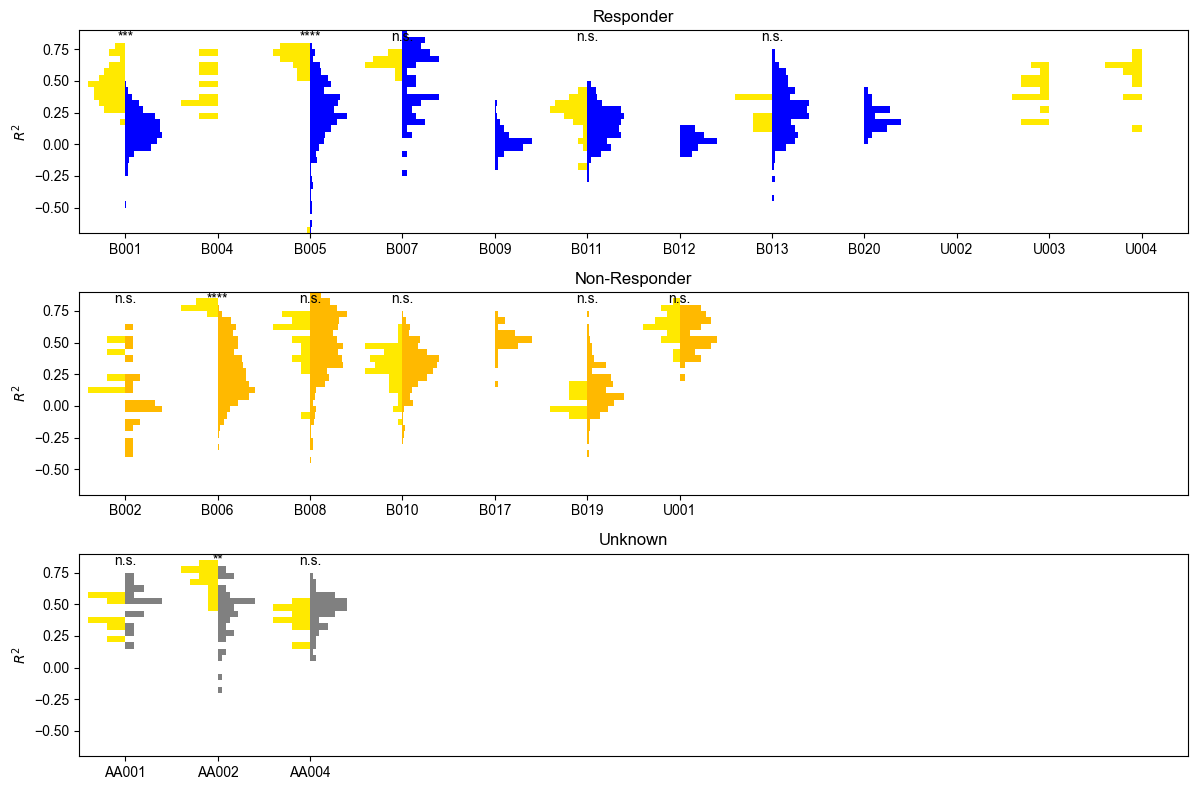

In [5]:
feature = 'lfp_right_OvER_interpolate_R2'
fig, axs = plt.subplots(nrows=3, figsize=(12, 8), sharey=True)
min_val, max_val = df[feature].min(), df[feature].max()
bin_start = np.floor(min_val*10)/10
bin_end = np.ceil(max_val*10)/10
bin_width = 0.05
bins = np.arange(bin_start, bin_end + bin_width, bin_width)

results_dict = {'pt_id': [], 't_stat': [], 'p_val': []}
only_first_14d = False

max_num_pts = 0
df.sort_values(by=['pt_id', 'dummy_timestamp'], inplace=True)
for ax, response_status in zip(axs, ['Responder', 'Non-Responder', 'Unknown']):
    plot_df = df.dropna(subset=feature).query('response_status == @response_status').copy()
    if only_first_14d:
        plot_df = plot_df.query('days_since_dbs <= 14')
    
    max_num_pts = max(max_num_pts, plot_df['pt_id'].nunique())
    for i, (pt_id, pt_df) in enumerate(plot_df.groupby('pt_id')):
        plot_df_daily = pt_df.dropna(subset=[feature]).groupby('days_since_dbs').first().reset_index()
        predbs_days, predbs_vals = plot_df_daily.query('state_label_str == "Pre-DBS"')[['days_since_dbs', feature]].values.T
        stable_state_days, stable_state_vals = plot_df_daily.query('state_label_str == @response_status')[['days_since_dbs', feature]].values.T
        if len(predbs_vals) != 0 and not np.isnan(predbs_vals).all():
            counts_predbs, _ = np.histogram(predbs_vals, bins=bins, density=True)
            counts_predbs /= counts_predbs.max() * 2.5
        else:
            counts_predbs = np.zeros(len(bins)-1)
        if len(stable_state_vals) != 0 and not np.isnan(stable_state_vals).all():
            counts_postdbs, _ = np.histogram(stable_state_vals, bins=bins, density=True)
            counts_postdbs /= counts_postdbs.max() * 2.5
        else:
            counts_postdbs = np.zeros(len(bins)-1)
        ax.barh(bins[:-1], -counts_predbs, height=bin_width, align='edge', left=i,
                color=COL_PAL['Pre-DBS'], edgecolor=None)
        ax.barh(bins[:-1], counts_postdbs, height=bin_width, align='edge', left=i,
                color=COL_PAL[response_status], edgecolor=None)

        # Run a t-test and annotate significance
        if len(predbs_vals) > 1 and len(stable_state_vals) > 1 and not np.isnan(predbs_vals).all() and not np.isnan(stable_state_vals).all():
            t_stat, p_val = ttest_ind_with_neff_correction(predbs_vals, stable_state_vals, predbs_days, stable_state_days)
            ax.text(i, bins[-1], get_asterisk_str(p_val), ha='center', va='top')
        else:
            t_stat, p_val = np.nan, np.nan
        results_dict['pt_id'].append(pt_id)
        results_dict['t_stat'].append(t_stat)
        results_dict['p_val'].append(p_val)
        
    ax.set(title=f'{response_status}',
           xticks=np.arange(plot_df['pt_id'].nunique()),
           xticklabels=plot_df['pt_id'].unique(),)

for ax in axs:
    ax.set(
        xlim=(-0.5, max_num_pts - 0.5),
        ylim=(bin_start, bin_end),
        ylabel=r'$R^2$',
    )

fig.tight_layout()
plt.show()

## B

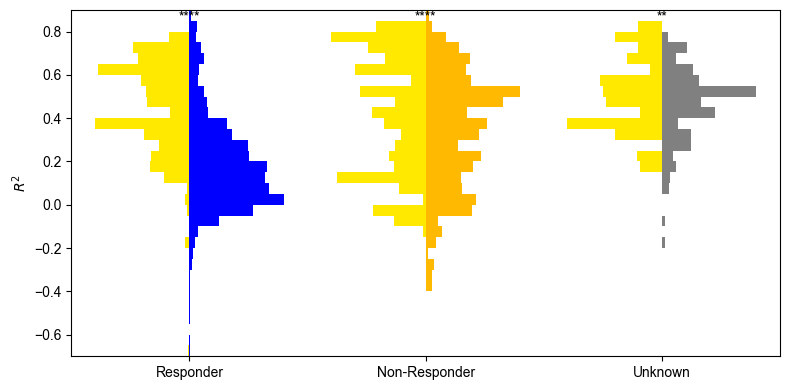

In [6]:
feature = 'lfp_right_OvER_interpolate_R2'
fig, ax = plt.subplots(figsize=(8, 4))
min_val, max_val = df[feature].min(), df[feature].max()
bin_start = np.floor(min_val*10)/10
bin_end = np.ceil(max_val*10)/10
bin_width = 0.05
bins = np.arange(bin_start, bin_end + bin_width, bin_width)

for i, response_status in enumerate(['Responder', 'Non-Responder', 'Unknown']):
    plot_df = df.query('response_status == @response_status')
    plot_df_daily = plot_df.dropna(subset=[feature]).groupby(['pt_id', 'days_since_dbs']).first().reset_index()
    predbs_vals = plot_df_daily.query('state_label_str == "Pre-DBS"')[feature]
    predbs_weights = []
    for pt_id, pt_df in plot_df_daily.groupby('pt_id'):
        num_predbs = pt_df.query('state_label_str == "Pre-DBS"')[feature].shape[0]
        if num_predbs > 0:
            predbs_weights.extend([1/num_predbs] * num_predbs)
    postdbs_vals = plot_df_daily.query('state_label_str == @response_status')[feature]
    postdbs_weights = []
    for pt_id, pt_df in plot_df_daily.groupby('pt_id'):
        num_postdbs = pt_df.query('state_label_str == @response_status')[feature].shape[0]
        if num_postdbs > 0:
            postdbs_weights.extend([1/num_postdbs] * num_postdbs)

    if not predbs_vals.empty and not predbs_vals.isna().all():
        counts_predbs, _ = np.histogram(predbs_vals, bins=bins, density=True, weights=predbs_weights)
        counts_predbs /= counts_predbs.max() * 2.5
    else:
        counts_predbs = np.zeros(len(bins)-1)
    if not postdbs_vals.empty and not postdbs_vals.isna().all():
        counts_postdbs, _ = np.histogram(postdbs_vals, bins=bins, density=True, weights=postdbs_weights)
        counts_postdbs /= counts_postdbs.max() * 2.5
    else:
        counts_postdbs = np.zeros(len(bins)-1)

    ax.barh(bins[:-1], -counts_predbs, height=bin_width, align='edge', left=i,
            color=COL_PAL['Pre-DBS'], edgecolor=None)
    ax.barh(bins[:-1], counts_postdbs, height=bin_width, align='edge', left=i,
            color=COL_PAL[response_status], edgecolor=None)

    # Run a t-test and annotate significance
    if len(predbs_vals) > 1 and len(postdbs_vals) > 1 and not predbs_vals.isna().all() and not postdbs_vals.isna().all():
        t_stat, p_val = stats.ttest_ind(predbs_vals, postdbs_vals, nan_policy='omit')
        predbs_feature_mean = np.mean(predbs_vals) if len(predbs_vals) > 0 and not np.isnan(predbs_vals).all() else np.nan
        postdbs_feature_mean = np.mean(postdbs_vals) if len(postdbs_vals) > 0 and not np.isnan(postdbs_vals).all() else np.nan
        predbs_feature_var = np.var(predbs_vals, ddof=1) if len(predbs_vals) > 1 and not np.isnan(predbs_vals).all() else np.nan
        postdbs_feature_var = np.var(postdbs_vals, ddof=1) if len(postdbs_vals) > 1 and not np.isnan(postdbs_vals).all() else np.nan
        cohens_d = (predbs_feature_mean - postdbs_feature_mean) / (np.sqrt((predbs_feature_var + postdbs_feature_var) / 2)) if not np.isnan(predbs_feature_var) and not np.isnan(postdbs_feature_var) and predbs_feature_var > 0 and postdbs_feature_var > 0 else np.nan
        ax.text(i, bins[-1], get_asterisk_str(p_val), ha='center', va='top')

ax.set(
    xlim=(-0.5, 2.5),
    ylim=(bin_start, bin_end),
    ylabel=r'$R^2$',
    xticks=np.arange(3),
    xticklabels=['Responder', 'Non-Responder', 'Unknown'],
)

fig.tight_layout()
plt.show()

## C

T-test comparing ΔR² between Responders and Non-Responders: t=-0.597, p=5.651e-01


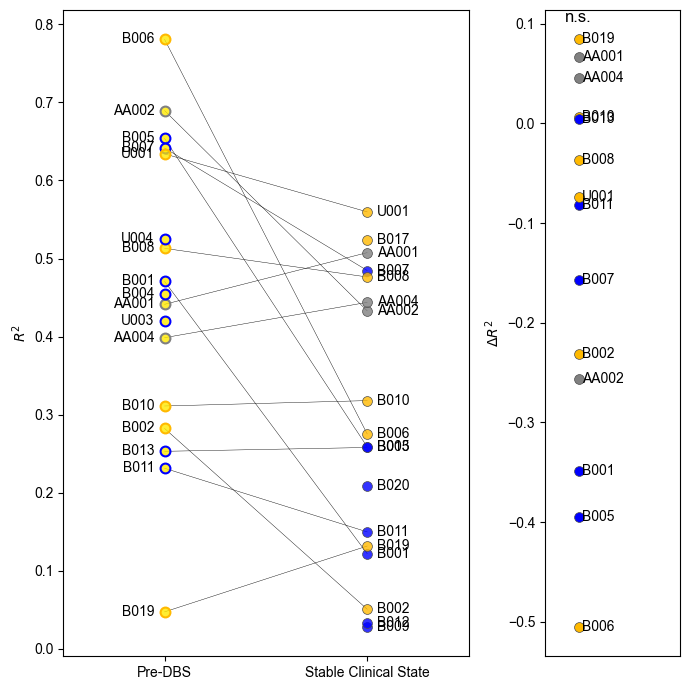

In [7]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 7), width_ratios=[3,1])
side_buffer = 0.5
text_buffer = 0.05
s = 50  # size of the scatter points
alpha = 0.8  # transparency for insides of the scatter points
    
feature = f'lfp_right_OvER_interpolate_R2'
postdbs_query_string = f'(days_since_dbs > 0) and (state_label_str in ["Unknown", "Responder", "Non-Responder"])'
clothesline_df = df.dropna(subset=[feature, 'response_status', 'state_label_str'], how='any').copy()

r_deltas, nr_deltas = [], []
for pt_id, pt_df in clothesline_df.groupby('pt_id'):
    pre_dbs_y = pt_df.query(f'state_label_str == "Pre-DBS"')[feature].mean()
    response_state = pt_df['response_status'].iloc[0]
    post_dbs_y = pt_df.query(postdbs_query_string)[feature].mean()
    delta_y = post_dbs_y - pre_dbs_y
    axs[0].scatter(0, pre_dbs_y, marker='o', color=add_alpha_to_color(COL_PAL['Pre-DBS'], alpha), s=s, edgecolors=COL_PAL[response_state], lw=1.5)
    axs[0].scatter(1, post_dbs_y, marker='o', color=add_alpha_to_color(COL_PAL[response_state], alpha), s=s, edgecolors='#4c4c4c', lw=0.5)
    axs[0].plot([0, 1], [pre_dbs_y, post_dbs_y], c='k', lw=0.3, zorder=0)
    axs[0].text(0-text_buffer, pre_dbs_y, pt_id, ha='right', va='center')
    axs[0].text(1+text_buffer, post_dbs_y, pt_id, ha='left', va='center')

    axs[1].scatter(0, delta_y, marker='o', color=COL_PAL[response_state], s=s, edgecolors='#4c4c4c', lw=0.5)
    axs[1].text(0+text_buffer, delta_y, pt_id, ha='left', va='center')
    if not np.isnan(delta_y):
        match response_state:
            case 'Responder':
                r_deltas.append(delta_y)
            case 'Non-Responder':
                nr_deltas.append(delta_y)

t_stat, p_val = stats.ttest_ind(r_deltas, nr_deltas, equal_var=False)
print(f'T-test comparing ΔR² between Responders and Non-Responders: t={t_stat:.3f}, p={p_val:.3e}')
axs[1].text(0, axs[1].get_ylim()[1], get_asterisk_str(p_val), ha='center', va='top', fontsize=8*1.5, color='k')
axs[0].set(
    xticks=[0, 1],
    xticklabels=['Pre-DBS', 'Stable Clinical State'],
    ylabel=r'$R^2$',
    xlim=[-side_buffer, 1 + side_buffer],
)
axs[1].set(
    xticks=[],
    xlim=[-side_buffer, 1 + side_buffer],
    ylabel=r'$\Delta R^2$'
)

fig.tight_layout()
plt.show()

## Partial Response Supp Fig

In [8]:
scale_df = pd.read_parquet('data/scale_df_for_paper.parq')

def adjust_state_labels(group_df):
    pt = group_df.pt_id.iloc[0]
    group_df = group_df.sort_values('days_since_dbs')
    init_yb = max(scale_df.query('pt_id == @pt and YBOCS_reduction == 0.0')['YBOCS'])
    group_df['yb_red_per'] = (init_yb - group_df['most_recent_YBOCS_value']) / init_yb

    mask = (group_df['days_since_dbs'] > 0) & (~group_df['state_label_str'].isin(['Pre-DBS', 'Transition', 'Disinhibited']))
    bins = [-np.inf, 0.2499, 0.3499, np.inf]
    labels = ['Non-Responder', 'Partial Responder', 'Responder']
    group_df.loc[mask, 'state_label_str'] = pd.cut(group_df.loc[mask, 'yb_red_per'], bins=bins, labels=labels, include_lowest=True)

    return group_df

partial_df = df.groupby('pt_id', group_keys=False).apply(adjust_state_labels)

## A

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AA001_Pre-DBS vs. AA001_Non-Responder: Custom statistical test with Holm-Bonferroni correction, P_val:1.524e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AA002_Pre-DBS vs. AA002_Non-Responder: Custom statistical test with Holm-Bonferroni correction, P_val:8.947e-03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

AA004_Pre-DBS vs. AA004_Non-Responder: Custom statistical test with Holm-Bonferroni correction, P_val:3.746e-02
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 

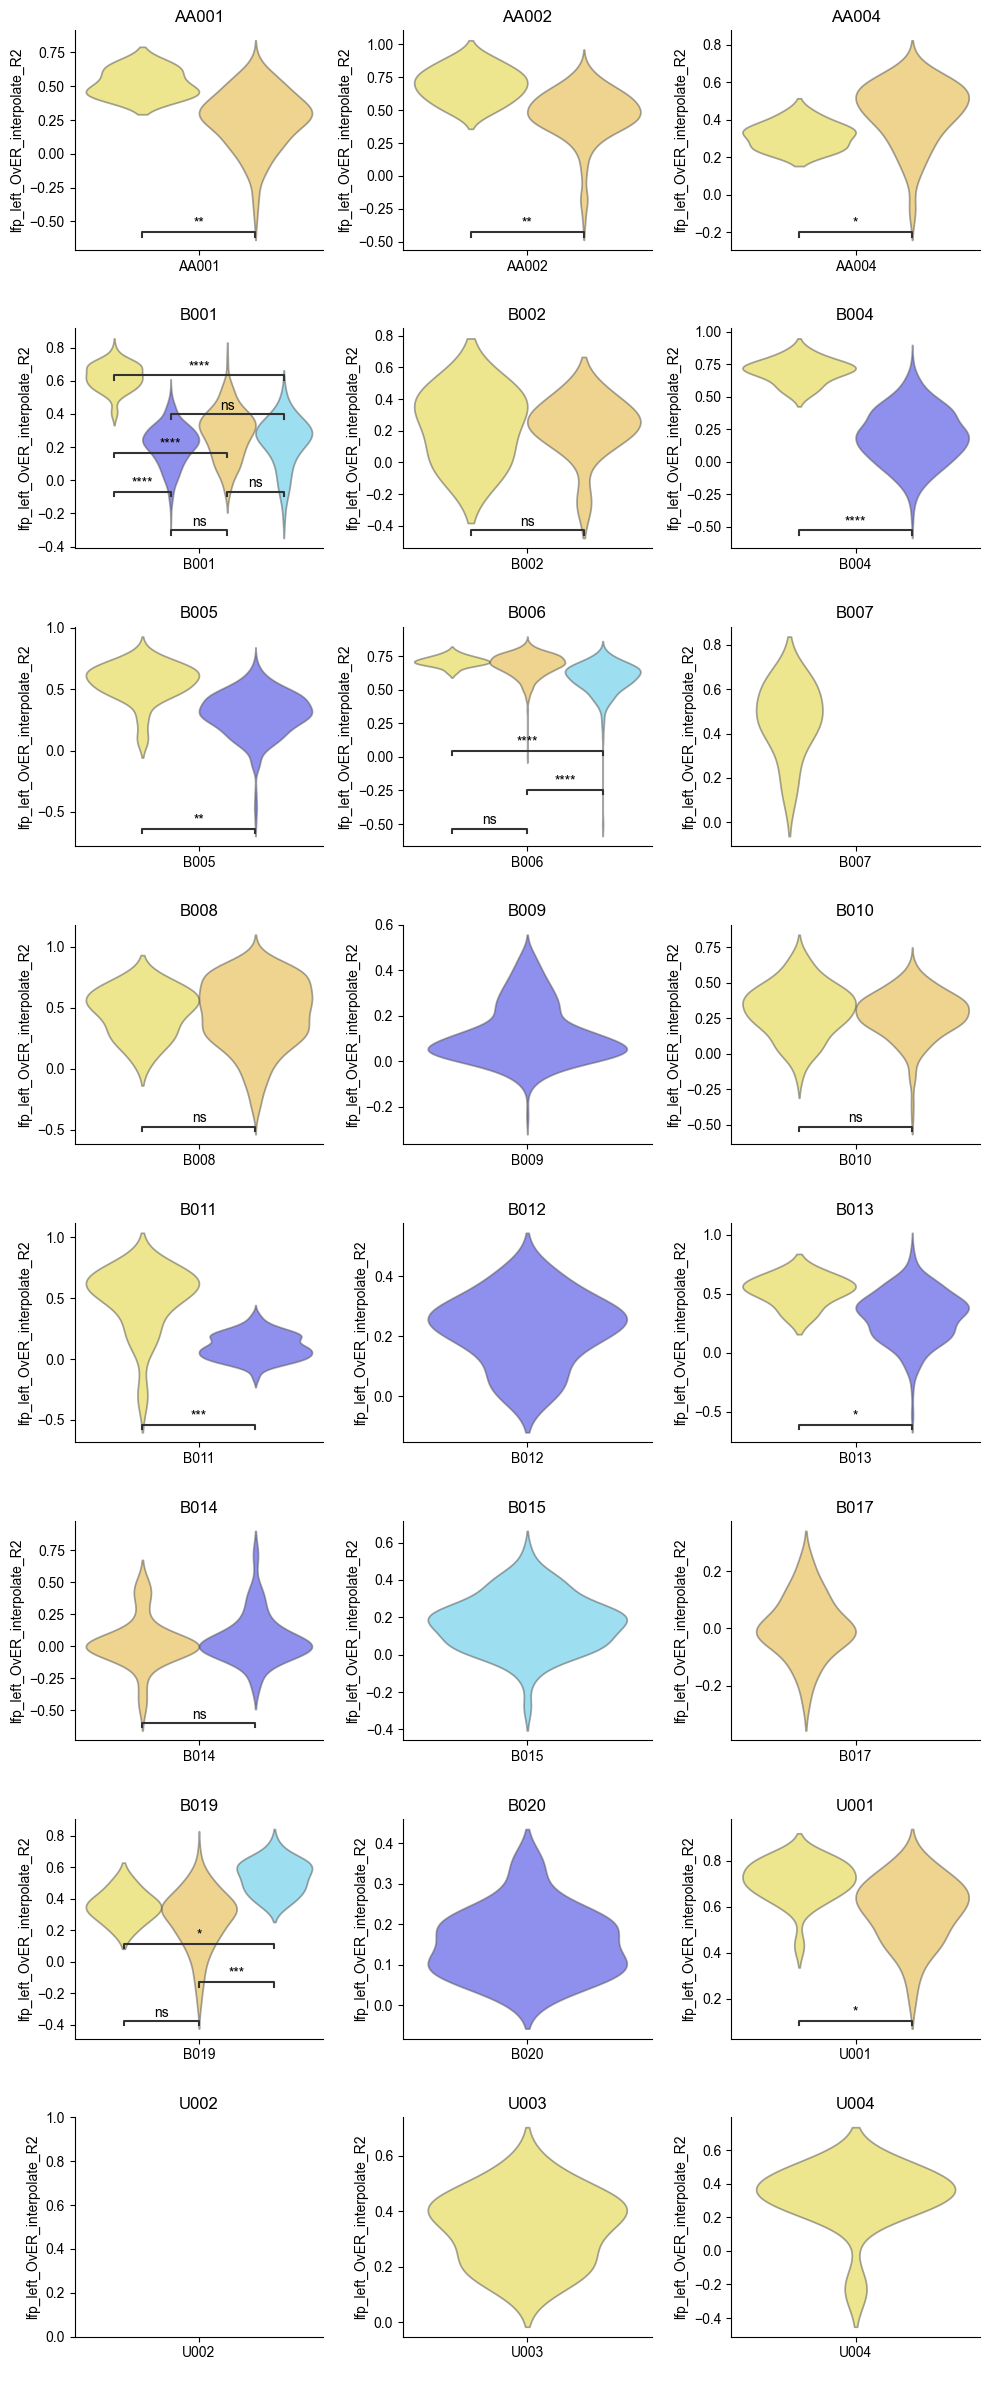

In [9]:
pts = partial_df.pt_id.unique()

fig, axes = plt.subplots(len(pts) // 3, 3, figsize=(10, len(pts) // 3 * 3))
states = ['Pre-DBS', 'Non-Responder', 'Partial Responder', 'Responder']

for pt, ax in zip(pts, axes.flatten()):
    pt_df = partial_df.query('pt_id == @pt and state_label_str in @states').drop_duplicates(subset=['days_since_dbs', 'pt_id'])

    pt_states = pt_df.state_label_str.unique()
    bp = sns.violinplot(pt_df, x = 'pt_id', y='lfp_left_OvER_interpolate_R2', hue='state_label_str', hue_order=pt_states, palette=COL_PAL, ax=ax, legend=False, fill=True, alpha=0.5, common_norm=False, inner=None)

    ax.set_title(pt)
    ax.set_xlabel(' ')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if len(pt_states) == 1:
        continue

    try:
        def get_values_and_days(df, state):
            sub = df.query('state_label_str == @state').dropna(subset='lfp_left_OvER_interpolate_R2')
            return (
                sub['lfp_left_OvER_interpolate_R2'].values,
                sub['days_since_dbs'].values,
            )

        pairs = list(combinations(pt_states, 2))
        pairs = [((pt, p[0]), (pt, p[1])) for p in pairs]

        pvalues = []
        for (x1, x2) in pairs:
            (pt1, s1), (pt2, s2) = x1, x2
            group1, days1 = get_values_and_days(pt_df, s1)
            group2, days2 = get_values_and_days(pt_df, s2)
            _, p = ttest_ind_with_neff_correction(group1, group2, days1, days2)
            pvalues.append(p)

        annot = Annotator(
            bp, pairs, data=pt_df,
            x='pt_id', y='lfp_left_OvER_interpolate_R2',
            hue='state_label_str', hue_order=list(pt_states),
        )
        annot.configure(
            test=None,                 # tell it not to run an internal test
            text_format='star',
            loc='inside',
            verbose=1,
            comparisons_correction='HB',
            correction_format='replace',
        )
        annot.set_pvalues_and_annotate(pvalues)
    except Exception:
        pass
    
fig.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Pre-DBS vs. Non-Responder: Custom statistical test with Holm-Bonferroni correction, P_val:5.139e-01
Partial Responder vs. Responder: Custom statistical test with Holm-Bonferroni correction, P_val:4.520e-03
Non-Responder vs. Partial Responder: Custom statistical test with Holm-Bonferroni correction, P_val:7.562e-01
Pre-DBS vs. Partial Responder: Custom statistical test with Holm-Bonferroni correction, P_val:4.327e-01
Non-Responder vs. Responder: Custom statistical test with Holm-Bonferroni correction, P_val:2.096e-07
Pre-DBS vs. Responder: Custom statistical test with Holm-Bonferroni correction, P_val:1.182e-07


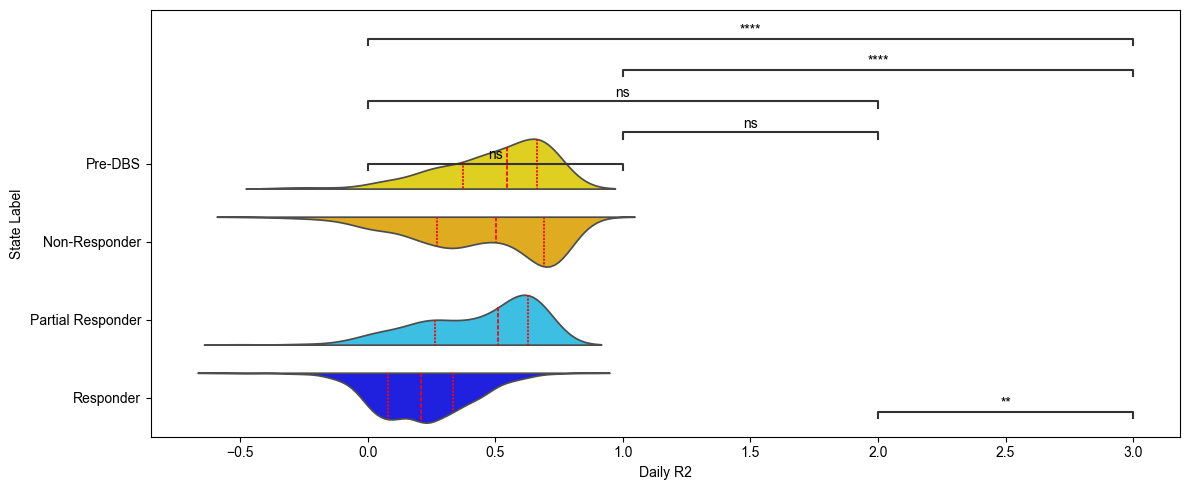

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
states = ['Pre-DBS', 'Non-Responder', 'Partial Responder', 'Responder']

# Grouped clinical state boxplot comparison 
plot_df = partial_df.query('state_label_str in @states and ~pt_id.str.contains("AA").values').drop_duplicates(subset=['days_since_dbs', 'pt_id'])
feature = 'lfp_left_OvER_interpolate_R2'
bp = sns.violinplot(plot_df, x=feature, y='state_label_str', inner='quart', palette=COL_PAL, ax=ax, legend=False, width=0.8, gap=0.2, order=states, split=True, inner_kws=dict(color='red'))

ax.set_xlabel('Daily R2')
ax.set_ylabel('State Label')

pairs = list(combinations(plot_df.state_label_str.unique(), 2))

pvalues = []
for (s1, s2) in pairs:
    group1, days1 = get_values_and_days(plot_df, s1)
    group2, days2 = get_values_and_days(plot_df, s2)
    days1 = [i for i in range(len(days1))]
    days2 = [i for i in range(len(days2))]
    _, p = ttest_ind_with_neff_correction(group1, group2, days1, days2)
    pvalues.append(p)

annot = Annotator(bp, pairs, data=plot_df, x='state_label_str', y=feature, width=1, gap=0.1, order=states)
annot.configure(
            test=None,                 # tell it not to run an internal test
            text_format='star',
            loc='inside',
            verbose=1,
            comparisons_correction='HB',
            correction_format='replace',
        )
annot.set_pvalues_and_annotate(pvalues)
fig.tight_layout()
plt.show()

## B

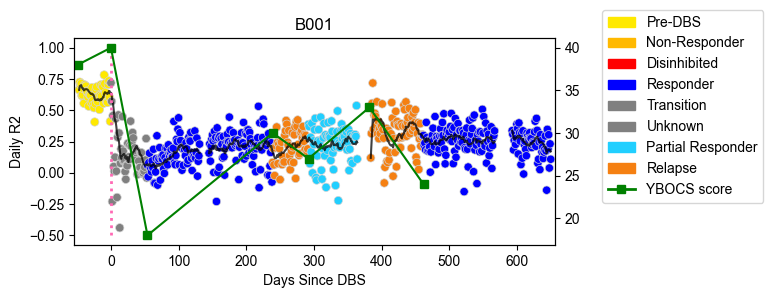

In [11]:
# B001 example relapse

fig, ax = plt.subplots(1, 1, figsize=(6, 3))

pt_df = partial_df.query('pt_id == "B001"').drop_duplicates(subset='days_since_dbs').sort_values('days_since_dbs')
pt_df.loc[pt_df['state_label_str'] == 'Non-Responder', 'state_label_str'] = 'Relapse'

sns.scatterplot(data=pt_df, x='days_since_dbs', y='lfp_left_OvER_interpolate_R2', hue='state_label_str', hue_order=df.state_label_str.unique(), palette=COL_PAL, ec='lightgray', ax=ax, legend=False)
ax.plot(pt_df.days_since_dbs, pt_df.left_R2_rolling_avg_14d, color='black', alpha=0.75)
ax.vlines(0, ymin=-0.5, ymax=1, ls='dotted', colors='hotpink', lw=2)

scale_ax = ax.twinx()
scale_df = pt_df.drop_duplicates(subset='most_recent_YBOCS_value')
scale_ax.plot(scale_df.days_since_dbs, scale_df.most_recent_YBOCS_value, marker='s', color='green')

ax.set_title('B001')
ax.set_ylabel('Daily R2')
ax.set_xlabel('Days Since DBS')
ax.set_xlim(pt_df.days_since_dbs.iloc[0]-5, pt_df.days_since_dbs.iloc[-1]+5)

handles = [mpatches.Patch(color=v, label=k) for k, v in COL_PAL.items()]
yb_line = mlines.Line2D([], [], color='green', linewidth=2, marker='s', label='YBOCS score')

fig.legend(handles=[*handles, yb_line], loc='upper left', bbox_to_anchor=(1, 1))
fig.tight_layout()
plt.show()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B001_Partial Responder vs. B001_Responder: Custom statistical test with Holm-Bonferroni correction, P_val:6.229e-01
B001_Pre-DBS vs. B001_Partial Responder: Custom statistical test with Holm-Bonferroni correction, P_val:3.096e-11
B001_Responder vs. B001_Relapse: Custom statistical test with Holm-Bonferroni correction, P_val:7.125e-02
B001_Pre-DBS vs. B001_Responder: Custom statistical test with Holm-Bonferroni correction, P_val:1.293e-14
B001_Partial Responder vs. B001_Relapse: Custom statistical test with Holm-Bonferroni correction, P_val:2.764e-01
B001_Pre-DBS vs. B001_Relapse: Custom statistical test with Holm-Bonferroni correction, P_val:3.114e-10


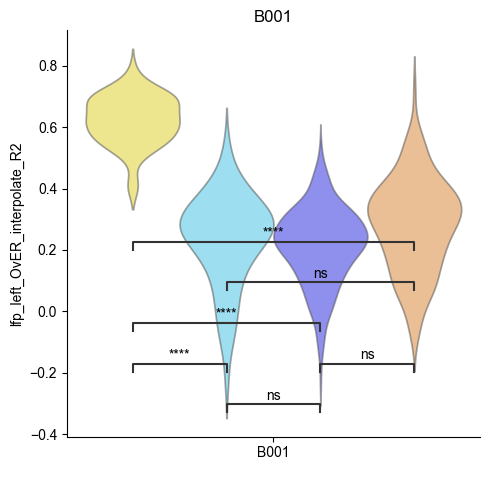

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

pt_states = ['Pre-DBS', 'Partial Responder', 'Responder', 'Relapse']
pt_df.query('state_label_str.isin(@pt_states)', inplace=True)
bp = sns.violinplot(pt_df, x='pt_id', y='lfp_left_OvER_interpolate_R2', hue='state_label_str', hue_order=pt_states, palette=COL_PAL, ax=ax, legend=False, fill=True, alpha=0.5, common_norm=False, inner=None)

ax.set_title('B001')
ax.set_xlabel(' ')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

state_pairs = list(combinations(pt_states, 2))
pairs = [(('B001', p[0]), ('B001', p[1])) for p in state_pairs]

pvalues = []
for (s1, s2) in state_pairs:
    group1, days1 = get_values_and_days(pt_df, s1)
    group2, days2 = get_values_and_days(pt_df, s2)
    _, p = ttest_ind_with_neff_correction(group1, group2, days1, days2)
    pvalues.append(p)

annot = Annotator(
    bp, pairs, data=pt_df,
    x='pt_id', y='lfp_left_OvER_interpolate_R2',
    hue='state_label_str', hue_order=list(pt_states),
)
annot.configure(
    test=None,                 # tell it not to run an internal test
    text_format='star',
    loc='inside',
    verbose=1,
    comparisons_correction='HB',
    correction_format='replace',
)
annot.set_pvalues_and_annotate(pvalues)

fig.tight_layout()
plt.show()

## LinAR-k Model Supp Figure

In [13]:
## LinAR-k model with 3 day sliding window

window_size = 3

ark_df = df.copy()
hem = 'left'

# Generate lag terms
lag_prefix = f"lfp_{hem}_OvER_interpolate_z_scored_lag_"
all_lags = [f"{lag_prefix}{i}" for i in range(1, 145)] # Up to 1 day of lag terms

groups_left = df.groupby(
        ["pt_id", "lead_location", "contig_left"], group_keys=False
)

for k, lag_label in tqdm(enumerate(all_lags), desc=f'Generating Lag terms for {hem} hem', total=len(all_lags)):
    if k == 0:
        continue
    join_df = groups_left.apply(
        lambda g: pd.DataFrame(
            {f"{lag_label}": g['lfp_left_OvER_interpolate_z_scored'].shift(periods=k+1)}
        ),
        include_groups=False,
    )
    
    ark_df = ark_df.join(join_df, how="left")


Generating Lag terms for left hem: 100%|██████████| 144/144 [02:58<00:00,  1.24s/it]


In [14]:
pt_groups = ark_df.groupby('pt_id', group_keys=False)

tqdm.pandas(desc=f'Applying LinAR-k model for {hem} hem')
hem_results_df = pt_groups.progress_apply(
    lambda g: apply_sliding_window(
        g, all_lags, f'lfp_{hem}_OvER_interpolate_z_scored', window_size=window_size),
    include_groups=False
)
ark_df = df.merge(
    hem_results_df,
    how='left',
    left_index=True,
    right_index=True,
    suffixes=('', '_ark')
)
ark_df.to_parquet('data/df_w_ark.parq')

Applying LinAR-k model for left hem: 100%|██████████| 24/24 [57:42<00:00, 144.28s/it]  


In [15]:
ark_df = pd.read_parquet('data/df_w_ark.parq')
ark_df.head(5)

,pt_id,time_bin_time,days_since_dbs,lfp_left_raw,stim_left,lfp_right_raw,stim_right,lead_location,left_lead_model,right_lead_model,...,left_delta_R2_rolling_avg_21d,left_delta_R2_rolling_avg_28d,lfp_right_OvER_interpolate_phi_1,lfp_right_OvER_interpolate_preds,lfp_right_OvER_interpolate_residuals,lfp_right_OvER_interpolate_R2,lfp_left_OvER_interpolate_phi_1_ark,lfp_left_OvER_interpolate_preds_ark,lfp_left_OvER_interpolate_residuals_ark,lfp_left_OvER_interpolate_R2_ark
0,AA001,22:30:00,-8,538.0,0.0,651.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AA001,22:40:00,-8,332.0,0.0,432.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AA001,22:50:00,-8,715.0,0.0,873.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AA001,23:00:00,-8,301.0,0.0,392.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AA001,23:10:00,-8,374.0,0.0,533.0,0.0,VC/VS,LEAD_B33015,LEAD_B33015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## A, B

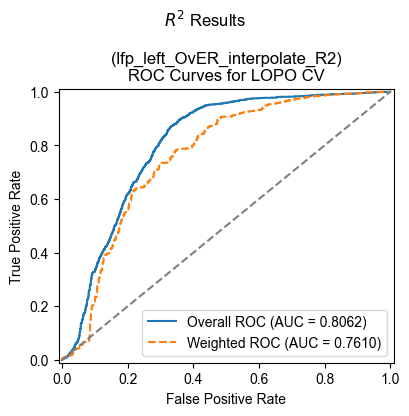

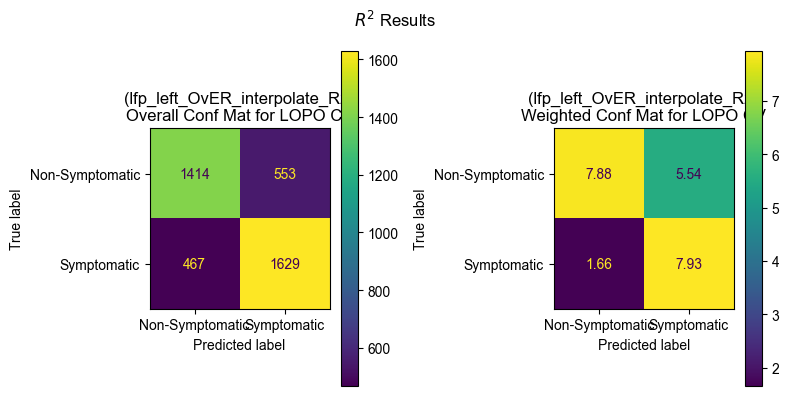

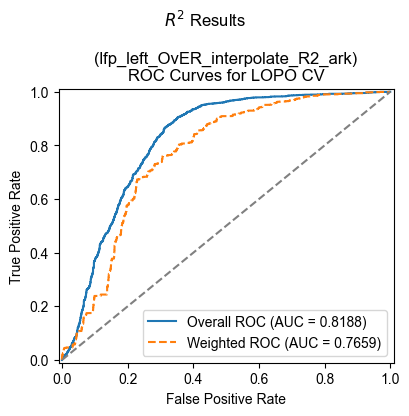

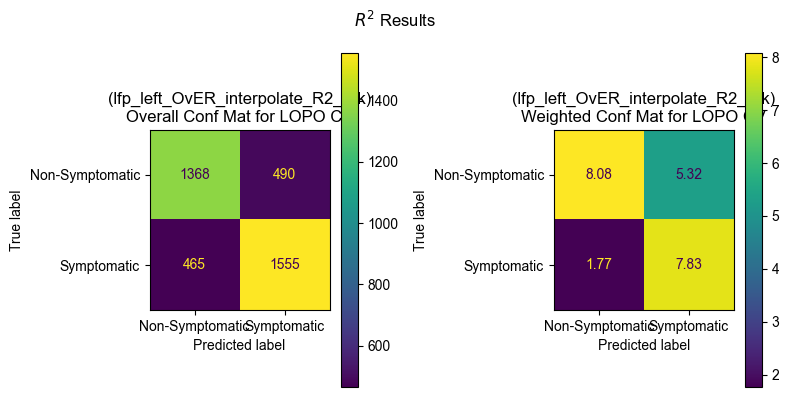

In [16]:
# Daily R2

daily_df = ark_df.groupby(by=['pt_id', 'days_since_dbs']).head(1)

feature_col = 'lfp_left_OvER_interpolate_R2'
for i, feature in enumerate(['ar1', 'ark']):
    if feature == 'ark':
        feature_col += '_ark'

    roc_fig, roc_ax = plt.subplots(figsize=(4.2, 4.2))
    conf_mat_fig, conf_mat_axs = plt.subplots(ncols=2, figsize=(8,4))

    results = leave_one_patient_out_logistic_regression(daily_df, [feature_col], roc_fig, roc_ax, conf_mat_fig, conf_mat_axs)
    [fig.suptitle(r'$R^2$' + ' Results') for fig in [roc_fig, conf_mat_fig]]
    [fig.tight_layout() for fig in [roc_fig, conf_mat_fig]]
    
    plt.show()


## C, D

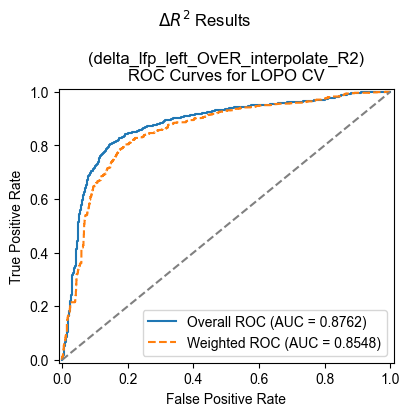

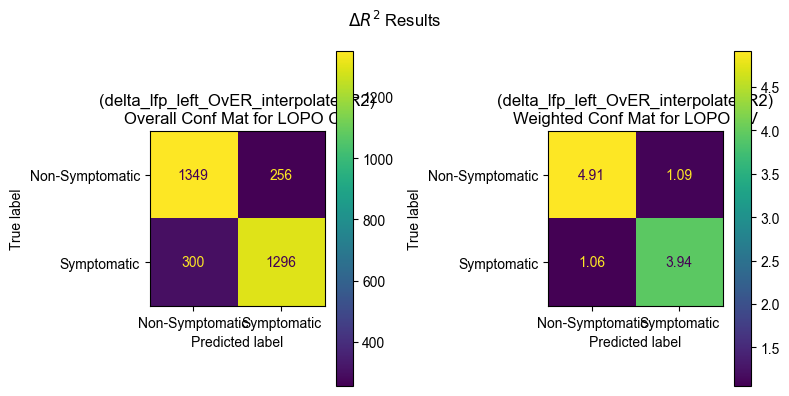

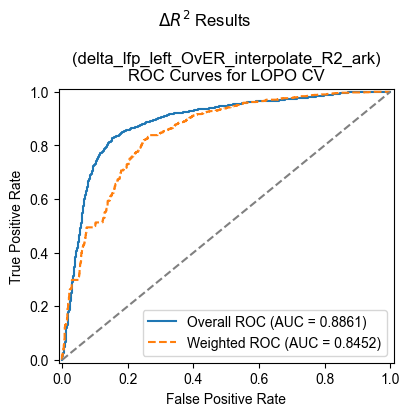

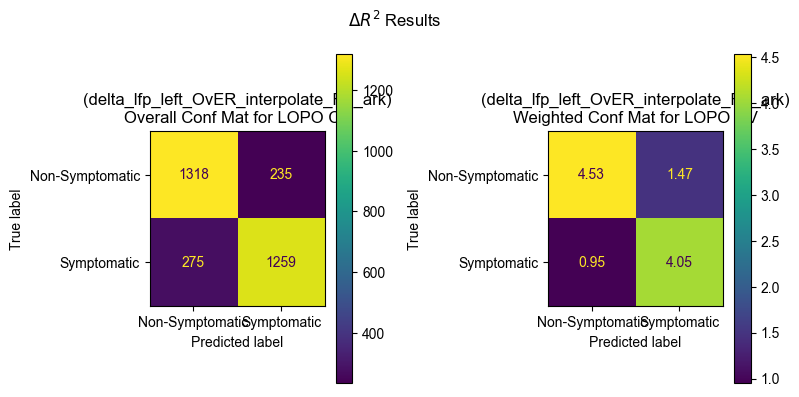

In [17]:
# Delta R2
feature_col = 'delta_lfp_left_OvER_interpolate_R2'

daily_df = delta_model(daily_df, ['lfp_left_OvER_interpolate_R2_ark'])

for i, feature in enumerate(['ar1', 'ark']):
    if feature == 'ark':
        feature_col += '_ark'

    roc_fig, roc_ax = plt.subplots(figsize=(4.2, 4.2))
    conf_mat_fig, conf_mat_axs = plt.subplots(ncols=2, figsize=(8,4))

    results = leave_one_patient_out_logistic_regression(daily_df, [feature_col], roc_fig, roc_ax, conf_mat_fig, conf_mat_axs)
    [fig.suptitle(r'$\Delta R^2$' + ' Results') for fig in [roc_fig, conf_mat_fig]]
    [fig.tight_layout() for fig in [roc_fig, conf_mat_fig]]
    
    plt.show()

## Delta $R^2$ Video Supp Figure

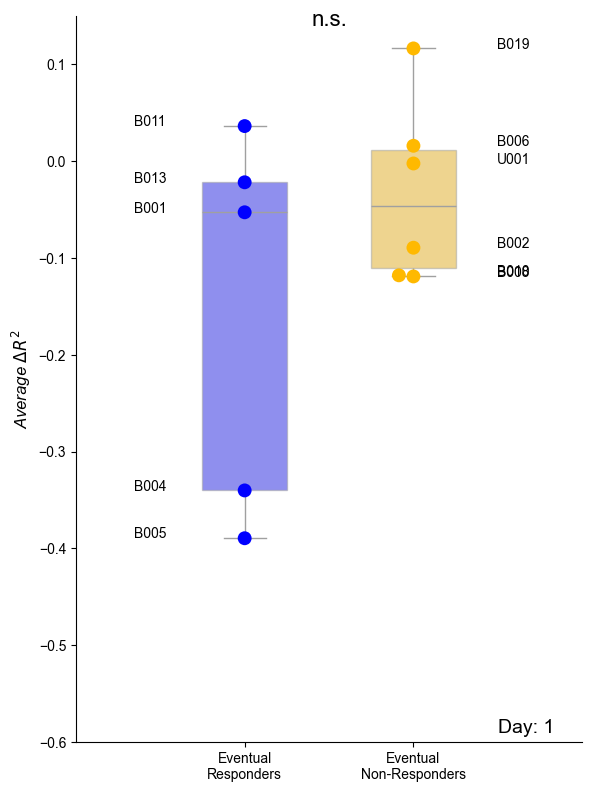

In [18]:
plt.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe() # Must have ffmpeg installed locally

text_font = 16
feature = 'delta_lfp_left_OvER_interpolate_R2'

def label_plot(day_df, sw, ax):
    for i, row in day_df.iterrows():
        if row['response_status'] == 'Responder':
            sw.annotate(row['pt_id'], (0, row['avg_delta_r2']), 
                        textcoords="offset points", xytext=(-80,0), ha='left')
        else:
            sw.annotate(row['pt_id'], (1, row['avg_delta_r2']), 
                        textcoords="offset points", xytext=(60,0), ha='left')

fig, ax = plt.subplots(figsize=(6, 8))

def animate(day):
    ax.cla() 
    init_df = daily_df.query('days_since_dbs == 1 and response_status != "Unknown" and pt_id != "U003"')

    avg_delta_r2 = daily_df.groupby(by='pt_id').apply(lambda g, day=day: np.nanmean(g.query('0 < days_since_dbs <= @day')[feature]))
    init_df = init_df.merge(avg_delta_r2.rename('avg_delta_r2'), left_on='pt_id', right_index=True, how='left')

    bp = sns.boxplot(data=init_df, x='response_status', y='avg_delta_r2', palette=[COL_PAL['Responder'], COL_PAL['Non-Responder']], ax=ax, showmeans=False, width=0.5, linewidth=1, showfliers=False, fill=True, boxprops=dict(alpha=0.5), linecolor='#a0a0a0')
    sw = sns.swarmplot(data=init_df, x='response_status', y='avg_delta_r2', palette=[COL_PAL['Responder'], COL_PAL['Non-Responder']], ax=ax, edgecolor='#4c4c4c', alpha=1, s=10)
    label_plot(init_df, sw, ax)
    
    t, p = stats.ttest_ind(init_df[init_df['response_status'] == 'Responder']['avg_delta_r2'].dropna(), init_df[init_df['response_status'] == 'Non-Responder']['avg_delta_r2'].dropna(), equal_var=False)
    sig_text = get_asterisk_str(p)
    
    
    sig = ax.text(0.5, 0.15 - 0.01, sig_text, fontsize=text_font, 
                  fontstyle='italic' if sig_text == "ns" else 'normal', ha='center')
    day_label = ax.text(1.5, -0.6 + 0.01, f'Day: {day}', fontsize=14)
    
    ax.set_xlabel('')
    ax.set_ylabel(r'Average $\Delta R^2$', fontsize=12, fontstyle='italic')
    ax.set_ylim(-0.6, 0.15)
    ax.set_xticklabels(['Eventual\nResponders', 'Eventual\nNon-Responders'])
    ax.tick_params(axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.margins(x=0.5)
    
    fig.tight_layout(pad=1)
    return bp, sw, sig, day_label

ani = animation.FuncAnimation(fig, animate, frames=np.arange(1, 501, step=1), interval=1, blit=False, repeat=True)

FFwriter = animation.FFMpegWriter(fps=3)
ani.save("figures/r2_over_time.mp4", writer=FFwriter)

## Polar & FFT Supp Figure

In [19]:
# FFT calculation
def run_day(df, num_days=0):
    subs = df["pt_id"].unique()
    features_ = []

    for sub in tqdm(subs):

        df_sub = df.query("pt_id == @sub")
        days = df_sub['days_since_dbs'].unique()
        response_ = df_sub["state_label_str"]
        response = []  
        data_day = []

        f_ = []
        response_day = []
        for day in days:
            idx = df_sub["days_since_dbs"] == day
            if idx.sum() > 0:
                response = response_[idx].values[0]
                # leave out Disinhibited and Transition phases
                if response != "Responder" and response != "Pre-DBS" and response != "Non-Responder":
                    continue

            idx_week = np.logical_and(df_sub["days_since_dbs"] >= (day - num_days), df_sub["days_since_dbs"] <= day)

            series_week = df_sub[idx_week][["dummy_timestamp", "lfp_left_OvER_interpolate_z_scored",
                                            "lfp_right_OvER_interpolate_z_scored",
                                            "delta_lfp_left_OvER_interpolate_R2"]].set_index("dummy_timestamp")
            series_week_resample = series_week.resample("30min").mean().interpolate(method="linear")

            if series_week_resample.shape[0] != (num_days+1)*24*2:
                continue
            data = series_week_resample.values
            time = series_week_resample.index

            power_6h_left = None
            power_12h_left = None
            power_24h_left = None
            power_6h_left_normed = None
            power_12h_left_normed = None
            power_24h_left_normed = None
            Hjorth_activity_left = None
            Hjorth_mobility_left = None
            Hjorth_complexity_left = None
            power_6h_right = None
            power_12h_right = None
            power_24h_right = None
            power_6h_right_normed = None
            power_12h_right_normed = None
            power_24h_right_normed = None
            Hjorth_activity_right = None
            Hjorth_mobility_right = None
            Hjorth_complexity_right = None
            Pxx_left = None
            Pxx_right = None
            power_left_sum = None
            power_right_sum = None
            delta_lfp_left_OvER_interpolate_dayR2 = None

            for data_idx in range(data.shape[1]):
                if "R2" in series_week_resample.columns[data_idx]:
                    continue
                if np.nan_to_num(data[:, data_idx]).sum() != 0:
                    data[:, data_idx] = stats.zscore(data[:, data_idx])
                    f, Pxx = welch(data[:, data_idx], fs=1, nperseg=data.shape[0])
                    Pxx = Pxx[1:][::-1]
                    # Pxx = stats.zscore(Pxx[1:][::-1])
                    time_periods = np.array((30/60)*1/f[1:]).round(2)[::-1]
                    if "left" in series_week_resample.columns[data_idx]:
                        hem = "left"
                        Pxx_left = Pxx
                    elif "right" in series_week_resample.columns[data_idx]:
                        hem = "right"
                        Pxx_right = Pxx

                    idx_6_h = np.where(time_periods == 6)[0]
                    idx_12_h = np.where(time_periods == 12)[0]
                    idx_24_h = np.where(time_periods == 24)[0]

                    if hem == "left":  # left hemisphere
                        power_6h_left = Pxx[idx_6_h][0] if idx_6_h.size > 0 else np.nan
                        power_12h_left = Pxx[idx_12_h][0] if idx_12_h.size > 0 else np.nan
                        power_24h_left = Pxx[idx_24_h][0] if idx_24_h.size > 0 else np.nan
                        power_6h_left_normed = power_6h_left / Pxx.sum() if Pxx.sum() != 0 else np.nan
                        power_12h_left_normed = power_12h_left / Pxx.sum() if Pxx.sum() != 0 else np.nan
                        power_24h_left_normed = power_24h_left / Pxx.sum() if Pxx.sum() != 0 else np.nan
                        power_left_sum = Pxx_left.sum()
                        Hjorth_activity_left = np.var(data[:, data_idx])
                        Hjorth_mobility_left = np.sqrt(np.var(np.diff(data[:, data_idx]))) / Hjorth_activity_left
                        Hjorth_complexity_left = np.sqrt(np.var(np.diff(np.diff(data[:, data_idx])))) / np.var(np.diff(data[:, data_idx])) / np.sqrt(Hjorth_activity_left)
                        delta_lfp_left_OvER_interpolate_dayR2 = np.nanmean(data[:, 2])
                    elif hem == "right":  # right hemisphere
                        #power_7h_right = Pxx[idx_7_h][0] if idx_7_h.size > 0 else np.nan
                        power_6h_right = Pxx[idx_6_h][0] if idx_6_h.size > 0 else np.nan
                        power_12h_right = Pxx[idx_12_h][0] if idx_12_h.size > 0 else np.nan
                        power_24h_right = Pxx[idx_24_h][0] if idx_24_h.size > 0 else np.nan
                        power_6h_right_normed = power_6h_right / Pxx.sum() if Pxx.sum() != 0 else np.nan
                        power_12h_right_normed = power_12h_right / Pxx.sum() if Pxx.sum() != 0 else np.nan
                        power_24h_right_normed = power_24h_right / Pxx.sum() if Pxx.sum() != 0 else np.nan
                        power_right_sum = Pxx_right.sum()

                        Hjorth_activity_right = np.var(data[:, data_idx])
                        Hjorth_mobility_right = np.sqrt(np.var(np.diff(data[:, data_idx]))) / Hjorth_activity_right
                        Hjorth_complexity_right = np.sqrt(np.var(np.diff(np.diff(data[:, data_idx])))) / np.var(np.diff(data[:, data_idx])) / np.sqrt(Hjorth_activity_right)

            features_.append({
                "subject": sub,
                "date": day,
                "response": response,
                "power_6h_left": power_6h_left,
                "power_12h_left": power_12h_left,
                "power_24h_left": power_24h_left,
                "power_6h_left_normed": power_6h_left_normed,
                "power_12h_left_normed": power_12h_left_normed,
                "power_24h_left_normed": power_24h_left_normed,
                "Hjorth_activity_left": Hjorth_activity_left,
                "Hjorth_mobility_left": Hjorth_mobility_left,
                "Hjorth_complexity_left": Hjorth_complexity_left,
                "power_6h_right": power_6h_right,
                "power_12h_right": power_12h_right,
                "power_24h_right": power_24h_right,
                "power_6h_right_normed": power_6h_right_normed,
                "power_12h_right_normed": power_12h_right_normed,
                "power_24h_right_normed": power_24h_right_normed,
                "Hjorth_activity_right": Hjorth_activity_right,
                "Hjorth_mobility_right": Hjorth_mobility_right,
                "Hjorth_complexity_right": Hjorth_complexity_right,
                "power_left_sum": power_left_sum,
                "power_right_sum": power_right_sum,
                "delta_lfp_left_OvER_interpolate_dayR2" : delta_lfp_left_OvER_interpolate_dayR2,
                "Pxx_left" : Pxx_left,
                "Pxx_right": Pxx_right
            })


    df_features = pd.DataFrame(features_)

    return df_features, time_periods

days = 3
if os.path.exists(f'data/df_features_previous_{days}days_normed_by_sum.pkl'):
    fft_df = pd.read_pickle(f'data/df_features_previous_{days}days_normed_by_sum.pkl')
    time_periods = pd.read_pickle(f"data/time_periods_{days}days.pkl")
else:
    fft_df, time_periods = run_day(df, days)
    
    fft_df.to_pickle(f"data/df_features_previous_{days}days_normed_by_sum.pkl")
    with open(f"data/time_periods_{days}days.pkl", "wb") as f:
        pickle.dump(time_periods, f)

In [20]:
# Plotting function
TITLE_SIZE = 3
LABEL_SIZE = 4
TICK_SIZE = 3
LEGEND_SIZE = 5
SUPTITLE_SIZE = 10
 
FIG_WIDTH_IN = 8.5
FIG_HEIGHT_IN = 11.0
 
plt.rcParams.update({
    "font.size": LABEL_SIZE,
    "axes.titlesize": TITLE_SIZE,
    "axes.labelsize": LABEL_SIZE,
    "xtick.labelsize": TICK_SIZE,
    "ytick.labelsize": TICK_SIZE,
    "legend.fontsize": LEGEND_SIZE,
    'axes.linewidth': 0.25,
    'xtick.major.width': 0.25,
    'ytick.major.width': 0.25,
    'xtick.major.pad': 1,
    'ytick.major.pad': 1,
    'axes.labelpad': 1
})

df = pd.read_parquet('data/df_for_paper.parq')

subs = fft_df['subject'].unique()
n_subs = len(subs)
n_rows = math.ceil(n_subs / 2)  # 2 patients per row -> 2 patient-columns
 
pdf_plt = PdfPages("figures/plot_spectra_polar_previous_3days.pdf")
 
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))
gs = gridspec.GridSpec(n_rows, 8, figure=fig, hspace=0.7, wspace=0.4)
 
def plot_subject_block(sub, row_idx, col_offset):
    """Draws one subject's 4 panels (L spectrum, R spectrum, L polar, R polar)
    starting at grid column `col_offset` in row `row_idx`."""
    df_sub = fft_df.query("subject == @sub")
 
    # FFT plots
    for lr_idx, hem in enumerate(["Pxx_left", "Pxx_right"]):
        ax = fig.add_subplot(gs[row_idx, col_offset + lr_idx])
        side = "L" if hem == "Pxx_left" else "R"
        ax.set_title(f"{sub}  ({side})", fontsize=TITLE_SIZE, fontweight="bold")
 
        resp_Pxx = []
        nonresp_Pxx = []
        preDBS_Pxx = []
        for idx, row in df_sub.iterrows():
            Pxx = row[hem]
            if isinstance(Pxx, str) is False:
                if not isinstance(Pxx, np.ndarray):
                    continue
            if math.isnan(Pxx[0]):
                continue
            responder_ = row["response"]
            if responder_ == "Responder":
                resp_Pxx.append(Pxx)
            elif responder_ == "Non-Responder":
                nonresp_Pxx.append(Pxx)
            elif responder_ == "Pre-DBS":
                preDBS_Pxx.append(Pxx)
            ax.plot(time_periods, Pxx, alpha=0.1, color=COL_PAL[responder_], linewidth=0.1)
 
        if nonresp_Pxx:
            nonresp_Pxx = np.array(nonresp_Pxx)
            mean_nonresp_Pxx = np.nanmean(nonresp_Pxx, axis=0)
            ax.plot(time_periods, mean_nonresp_Pxx, label="Non-Responder",
                     color=COL_PAL["Non-Responder"], linewidth=1)
        if resp_Pxx:
            resp_Pxx = np.array(resp_Pxx)
            mean_resp_Pxx = np.nanmean(resp_Pxx, axis=0)
            ax.plot(time_periods, mean_resp_Pxx, label="Responder",
                     color=COL_PAL["Responder"], linewidth=1)
        if preDBS_Pxx:
            preDBS_Pxx = np.array(preDBS_Pxx)
            mean_preDBS_Pxx = np.nanmean(preDBS_Pxx, axis=0)
            ax.plot(time_periods, mean_preDBS_Pxx, label="Pre-DBS",
                     color=COL_PAL["Pre-DBS"], linewidth=1)
 
        ax.set_xscale("log")
        ax.set_ylim(0, 100)
        ax.set_xlabel("Time period [h]", fontsize=LABEL_SIZE)
        ax.set_ylabel("Power [a.u.]", fontsize=LABEL_SIZE)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
 
    # Polar plots
    raw_pt_df = df.query("pt_id == @sub")
    for lr_idx, hem in enumerate(["left", "right"]):
        ax = fig.add_subplot(gs[row_idx, col_offset + 2 + lr_idx], projection="polar")
        side = "L" if hem == "left" else "R"
        ax.set_title(f"{sub}  ({side})", fontsize=TITLE_SIZE, fontweight="bold")
 
        mean_power = raw_pt_df.groupby(["time_bin_time", "state_label_str"]).apply(
            lambda g: np.nanmean(g[f"lfp_{hem}_OvER_interpolate_z_scored"]), include_groups=False
        ).reset_index(name="lfp_mean")
        std_power = raw_pt_df.groupby(["time_bin_time", "state_label_str"]).apply(
            lambda g: np.nanstd(g[f"lfp_{hem}_OvER_interpolate_z_scored"]), include_groups=False
        ).reset_index(name="lfp_std")
 
        for state in ["Pre-DBS", "Responder", "Non-Responder"]:
            state_power = mean_power.query("state_label_str == @state").sort_values(
                by="time_bin_time")["lfp_mean"].values
            state_std = std_power.query("state_label_str == @state").sort_values(
                by="time_bin_time")["lfp_std"].values
            if len(state_power) == 0:
                continue
            ax.plot(np.linspace(0.00, 2 * np.pi, 144), state_power, color=COL_PAL[state], lw=1)
            ax.fill_between(np.linspace(0.00, 2 * np.pi, 144),
                             state_power - state_std, state_power + state_std,
                             color=COL_PAL[state], alpha=0.5)
 
        ax.set_xticks(np.linspace(0.00, 2 * np.pi, 9),
                       ["0:00", "3:00", "6:00", "9:00", "12:00", "15:00", "18:00", "21:00", ""])
        ax.tick_params(axis="x", which='major', labelsize=TICK_SIZE, pad=-6)
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)
 
 
for pair_idx in range(n_rows):
    sub_a = subs[pair_idx * 2]
    plot_subject_block(sub_a, pair_idx, col_offset=0)
 
    b_index = pair_idx * 2 + 1
    if b_index < n_subs:
        sub_b = subs[b_index]
        plot_subject_block(sub_b, pair_idx, col_offset=4)
 
# ---- Single shared legend for the whole page ----
legend_handles = [
    mlines.Line2D([0], [0], color=COL_PAL["Pre-DBS"], lw=1.5, label="Pre-DBS"),
    mlines.Line2D([0], [0], color=COL_PAL["Responder"], lw=1.5, label="Responder"),
    mlines.Line2D([0], [0], color=COL_PAL["Non-Responder"], lw=1.5, label="Non-Responder"),
]

legend_ax = fig.add_subplot(gs[-1, 4:])
legend_ax.clear()
legend_ax.set_axis_off()
legend_ax.legend(handles=legend_handles, loc="center", ncol=3,
           fontsize=LEGEND_SIZE, frameon=False)
 
# fig.suptitle("Spectra & Circadian Power by Subject", fontsize=SUPTITLE_SIZE)
fig.tight_layout()
pdf_plt.savefig(fig, bbox_inches="tight")
plt.close(fig)
pdf_plt.close()